### E-Commerce Orders — Full Data Science Project
### Steps: EDA → Preprocessing → ML (Classification + Regression)

----

In [1]:
# 0. IMPORTS Libaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)
 
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#7F77DD", "#378ADD", "#1D9E75", "#EF9F27", "#E24B4A", "#D4537E", "#639922"]
 
print("=" * 60)
print("  E-COMMERCE DATA SCIENCE PROJECT")
print("=" * 60)

  E-COMMERCE DATA SCIENCE PROJECT


In [9]:
# 1. LOAD DATA

print("\n[1] Loading dataset...")
df = pd.read_excel('Dataset for Data Analytics (1).xlsx')
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
 


[1] Loading dataset...
Shape: 1200 rows × 14 columns
Columns: ['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


### 2. EXPLORATORY DATA ANALYSIS (EDA)

In [10]:
print("\n[2] Exploratory Data Analysis...")
 
print("\n--- Data Types ---")
print(df.dtypes)
 
print("\n--- First 5 Rows ---")
print(df.head())
 
print("\n--- Statistical Summary ---")
print(df.describe(include="all").T.to_string())
 
print("\n--- Missing Values ---")
mv = df.isnull().sum()
print(mv[mv > 0])
 
print("\n--- Value Counts: OrderStatus ---")
print(df["OrderStatus"].value_counts())
 
print("\n--- Value Counts: Product ---")
print(df["Product"].value_counts())


[2] Exploratory Data Analysis...

--- Data Types ---
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

--- First 5 Rows ---
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress Payment

### ── EDA Plots ──────────────────────────────────────────────

In [16]:
fig = plt.figure(figsize=(20, 22))
fig.suptitle("EDA — E-Commerce Orders Dataset", fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(4, 3, figure=fig,
                    #    hspace=0.55, wspace=0.35
                       )

plt.show()

<Figure size 2000x2200 with 0 Axes>

In [ ]:
# 1. OrderStatus bar

ax1 = fig.add_subplot(gs[0, 0])
vc = df["OrderStatus"].value_counts()
ax1.bar(vc.index, vc.values, color=COLORS[:len(vc)], edgecolor="white")
ax1.set_title("Order Status Distribution", fontsize=11, fontweight="bold")
ax1.set_xlabel("Status"); ax1.set_ylabel("Count")
ax1.tick_params(axis="x", rotation=20)
for i, v in enumerate(vc.values):
    ax1.text(i, v + 3, str(v), ha="center", fontsize=9)
    

In [17]:
# 2. Product bar

ax2 = fig.add_subplot(gs[0, 1])
vc2 = df["Product"].value_counts()
ax2.bar(vc2.index, vc2.values, color=COLORS[:len(vc2)], edgecolor="white")
ax2.set_title("Product Distribution", fontsize=11, fontweight="bold")
ax2.set_xlabel("Product"); ax2.set_ylabel("Count")
ax2.tick_params(axis="x", rotation=20)

In [18]:
# 3. PaymentMethod pie

ax3 = fig.add_subplot(gs[0, 2])
pm = df["PaymentMethod"].value_counts()
ax3.pie(pm.values, labels=pm.index, autopct="%1.1f%%", colors=COLORS[:len(pm)],
        startangle=90, textprops={"fontsize": 9})
ax3.set_title("Payment Method", fontsize=11, fontweight="bold")

Text(0.5, 1.0, 'Payment Method')

In [19]:
# 4. TotalPrice histogram
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(df["TotalPrice"], bins=30, color="#7F77DD", edgecolor="white", alpha=0.85)
ax4.set_title("TotalPrice Distribution", fontsize=11, fontweight="bold")
ax4.set_xlabel("Total Price ($)"); ax4.set_ylabel("Frequency")
 
# 5. UnitPrice histogram
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(df["UnitPrice"], bins=30, color="#378ADD", edgecolor="white", alpha=0.85)
ax5.set_title("UnitPrice Distribution", fontsize=11, fontweight="bold")
ax5.set_xlabel("Unit Price ($)"); ax5.set_ylabel("Frequency")

Text(0, 0.5, 'Frequency')

In [20]:
# 6. Quantity bar
ax6 = fig.add_subplot(gs[1, 2])
vc3 = df["Quantity"].value_counts().sort_index()
ax6.bar(vc3.index.astype(str), vc3.values, color="#1D9E75", edgecolor="white")
ax6.set_title("Quantity Distribution", fontsize=11, fontweight="bold")
ax6.set_xlabel("Quantity"); ax6.set_ylabel("Count")

Text(0, 0.5, 'Count')

In [21]:
# 7. Boxplot TotalPrice by Product
ax7 = fig.add_subplot(gs[2, :2])
df.boxplot(column="TotalPrice", by="Product", ax=ax7,
           boxprops=dict(color="#7F77DD"), medianprops=dict(color="#E24B4A", linewidth=2))
ax7.set_title("TotalPrice by Product", fontsize=11, fontweight="bold")
ax7.set_xlabel("Product"); ax7.set_ylabel("Total Price ($)")
plt.sca(ax7); plt.title("TotalPrice by Product"); plt.suptitle("")

Text(0.5, 0.98, '')

In [22]:
# 8. ReferralSource bar
ax8 = fig.add_subplot(gs[2, 2])
vc4 = df["ReferralSource"].value_counts()
ax8.barh(vc4.index, vc4.values, color=COLORS[:len(vc4)])
ax8.set_title("Referral Source", fontsize=11, fontweight="bold")
ax8.set_xlabel("Count")

Text(0.5, 0, 'Count')

In [23]:
# 9. Monthly orders trend
ax9 = fig.add_subplot(gs[3, :2])
df["YearMonth"] = df["Date"].dt.to_period("M")
monthly = df.groupby("YearMonth").size()
ax9.plot(monthly.index.astype(str), monthly.values, color="#7F77DD", marker="o",
         markersize=4, linewidth=2)
ax9.set_title("Monthly Order Trend", fontsize=11, fontweight="bold")
ax9.set_xlabel("Month"); ax9.set_ylabel("Orders")
ax9.tick_params(axis="x", rotation=45)
step = max(1, len(monthly) // 10)
ax9.set_xticks(ax9.get_xticks()[::step])

In [24]:
# 10. CouponCode usage
ax10 = fig.add_subplot(gs[3, 2])
coupon = df["CouponCode"].fillna("None").value_counts()
ax10.bar(coupon.index, coupon.values, color=COLORS[:len(coupon)], edgecolor="white")
ax10.set_title("Coupon Code Usage", fontsize=11, fontweight="bold")
ax10.set_xlabel("Coupon"); ax10.set_ylabel("Count")
 
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.close()
print("    ✅ EDA plots saved → eda_plots.png")

    ✅ EDA plots saved → eda_plots.png


 ─────────────────────────────────────────
##### 3. CORRELATION HEATMAP


In [25]:
print("\n[3] Correlation Analysis...")
num_cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]
corr = df[num_cols].corr()
print(corr.round(3).to_string())
 
fig2, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            mask=mask, ax=ax, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap — Numerical Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.close()
print("    ✅ Heatmap saved → correlation_heatmap.png")


[3] Correlation Analysis...
             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity        1.000      0.015        0.650       0.615
UnitPrice       0.015      1.000        0.001       0.717
ItemsInCart     0.650      0.001        1.000       0.393
TotalPrice      0.615      0.717        0.393       1.000
    ✅ Heatmap saved → correlation_heatmap.png


 ─────────────────────────────────────────
### 4. DATA PREPROCESSING

In [26]:
print("\n[4] Data Preprocessing...")
 
df_ml = df.copy()
 
# 4a. Drop non-informative columns
drop_cols = ["OrderID", "CustomerID", "TrackingNumber", "ShippingAddress", "YearMonth"]
df_ml.drop(columns=drop_cols, inplace=True)
print(f"    Dropped columns: {drop_cols}")
 
# 4b. Handle missing values
df_ml["CouponCode"] = df_ml["CouponCode"].fillna("None")
print(f"    Missing values after fill: {df_ml.isnull().sum().sum()}")
 
# 4c. Feature engineering from Date
df_ml["Year"]      = df_ml["Date"].dt.year
df_ml["Month"]     = df_ml["Date"].dt.month
df_ml["DayOfWeek"] = df_ml["Date"].dt.dayofweek
df_ml["Quarter"]   = df_ml["Date"].dt.quarter
df_ml.drop(columns=["Date"], inplace=True)
print("    Extracted Date features: Year, Month, DayOfWeek, Quarter")
 


[4] Data Preprocessing...
    Dropped columns: ['OrderID', 'CustomerID', 'TrackingNumber', 'ShippingAddress', 'YearMonth']
    Missing values after fill: 0
    Extracted Date features: Year, Month, DayOfWeek, Quarter


In [27]:
# 4d. Encode categorical features
cat_ohe = ["Product", "PaymentMethod", "ReferralSource", "CouponCode"]
df_ml = pd.get_dummies(df_ml, columns=cat_ohe, drop_first=False)
print(f"    One-hot encoded: {cat_ohe}")
print(f"    Shape after encoding: {df_ml.shape}")

    One-hot encoded: ['Product', 'PaymentMethod', 'ReferralSource', 'CouponCode']
    Shape after encoding: (1200, 30)


In [28]:
# 4e. Label encode target: OrderStatus
le = LabelEncoder()
df_ml["OrderStatus_encoded"] = le.fit_transform(df_ml["OrderStatus"])
print(f"    OrderStatus classes: {list(le.classes_)}")
df_ml.drop(columns=["OrderStatus"], inplace=True)
 
print(f"\n    Final preprocessed shape: {df_ml.shape}")

    OrderStatus classes: ['Cancelled', 'Delivered', 'Pending', 'Returned', 'Shipped']

    Final preprocessed shape: (1200, 30)


### 5. CLASSIFICATION — Predict OrderStatus

In [29]:
print("\n" + "=" * 60)
print("  [5] CLASSIFICATION: Predicting OrderStatus")
print("=" * 60)
 
# Features & target
X_cls = df_ml.drop(columns=["OrderStatus_encoded", "TotalPrice"])
y_cls = df_ml["OrderStatus_encoded"]
 
# Scale
scaler_cls = StandardScaler()
X_cls_scaled = scaler_cls.fit_transform(X_cls)
 
# Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls_scaled, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)
print(f"\n    Train size: {len(X_train_c)} | Test size: {len(X_test_c)}")
 


  [5] CLASSIFICATION: Predicting OrderStatus

    Train size: 960 | Test size: 240


In [30]:
# Define classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "SVM":                 SVC(kernel="rbf", random_state=42),
}
 
cls_results = {}
print("\n--- Model Comparison (Accuracy) ---")
print(f"{'Model':<25} {'Train Acc':>10} {'Test Acc':>10} {'CV Mean':>10} {'CV Std':>8}")
print("-" * 65)
 
for name, clf in classifiers.items():
    clf.fit(X_train_c, y_train_c)
    tr_acc = accuracy_score(y_train_c, clf.predict(X_train_c))
    te_acc = accuracy_score(y_test_c,  clf.predict(X_test_c))
    cv     = cross_val_score(clf, X_cls_scaled, y_cls, cv=5, scoring="accuracy")
    cls_results[name] = {"train": tr_acc, "test": te_acc, "cv_mean": cv.mean(), "cv_std": cv.std()}
    print(f"{name:<25} {tr_acc:>10.4f} {te_acc:>10.4f} {cv.mean():>10.4f} {cv.std():>8.4f}")
 


--- Model Comparison (Accuracy) ---
Model                      Train Acc   Test Acc    CV Mean   CV Std
-----------------------------------------------------------------
Logistic Regression           0.3021     0.2000     0.2250   0.0095
Decision Tree                 1.0000     0.2000     0.2017   0.0272
Random Forest                 1.0000     0.2042     0.1908   0.0210
Gradient Boosting             0.8000     0.2125     0.2000   0.0270
K-Nearest Neighbors           0.4500     0.1917     0.1892   0.0292
SVM                           0.5885     0.1958     0.1992   0.0340


In [31]:
# Best model detail
best_cls_name = max(cls_results, key=lambda k: cls_results[k]["test"])
best_clf = classifiers[best_cls_name]
print(f"\n    ⭐ Best classifier: {best_cls_name}  (Test Acc = {cls_results[best_cls_name]['test']:.4f})")
 
y_pred_best = best_clf.predict(X_test_c)
print(f"\n--- Classification Report ({best_cls_name}) ---")
print(classification_report(y_test_c, y_pred_best, target_names=le.classes_))


    ⭐ Best classifier: Gradient Boosting  (Test Acc = 0.2125)

--- Classification Report (Gradient Boosting) ---
              precision    recall  f1-score   support

   Cancelled       0.18      0.18      0.18        50
   Delivered       0.22      0.22      0.22        46
     Pending       0.28      0.38      0.32        47
    Returned       0.19      0.16      0.17        50
     Shipped       0.16      0.13      0.14        47

    accuracy                           0.21       240
   macro avg       0.21      0.21      0.21       240
weighted avg       0.21      0.21      0.21       240



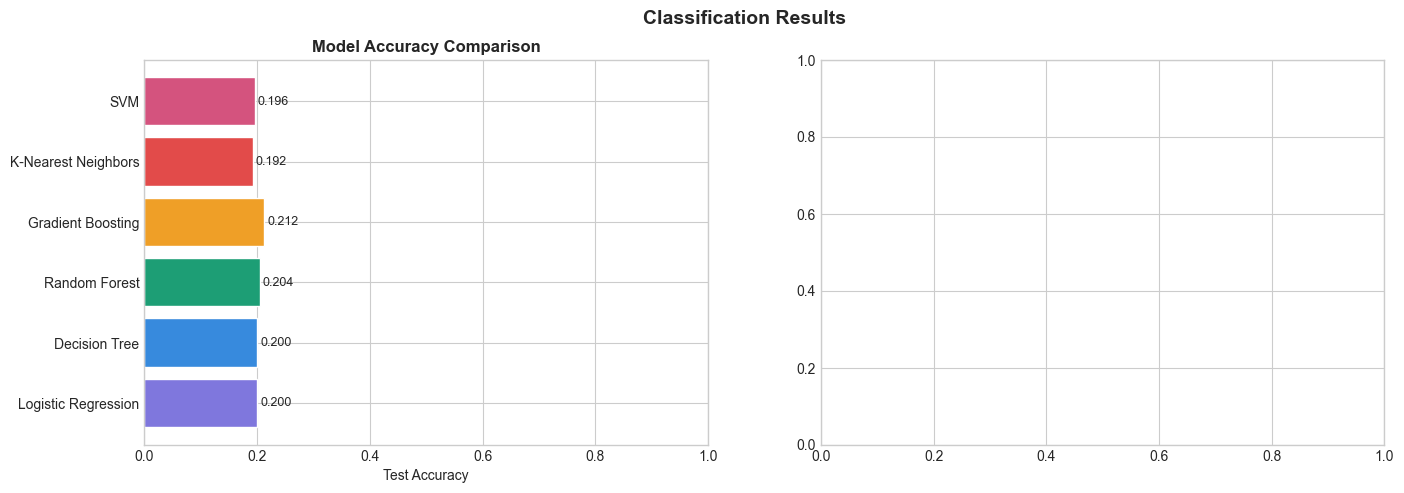

In [33]:
# ── Classification plots ──────────────────────────────────
fig3, axes = plt.subplots(1, 2, figsize=(16, 5))
fig3.suptitle("Classification Results", fontsize=14, fontweight="bold")
 
# Model accuracy comparison
names  = list(cls_results.keys())
test_a = [cls_results[n]["test"] for n in names]
bars = axes[0].barh(names, test_a, color=COLORS[:len(names)], edgecolor="white")
axes[0].set_xlabel("Test Accuracy")
axes[0].set_title("Model Accuracy Comparison", fontsize=12, fontweight="bold")
axes[0].set_xlim(0, 1)
for bar, val in zip(bars, test_a):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                 f"{val:.3f}", va="center", fontsize=9)

In [34]:
# Confusion matrix for best model
cm = confusion_matrix(y_test_c, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5)
axes[1].set_title(f"Confusion Matrix — {best_cls_name}", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].tick_params(axis="x", rotation=30)
 
plt.tight_layout()
plt.savefig("classification_results.png", dpi=150, bbox_inches="tight")
plt.close()
print("    ✅ Classification plots saved → classification_results.png")
 

    ✅ Classification plots saved → classification_results.png


In [35]:
# Feature importance (Random Forest)
rf_clf = classifiers["Random Forest"]
fi = pd.Series(rf_clf.feature_importances_, index=X_cls.columns).sort_values(ascending=False)
print("\n--- Top 10 Feature Importances (Random Forest) ---")
print(fi.head(10).round(4).to_string())
 
fig4, ax = plt.subplots(figsize=(9, 5))
fi.head(15).plot(kind="barh", ax=ax, color="#7F77DD", edgecolor="white")
ax.invert_yaxis()
ax.set_title("Top 15 Feature Importances — Random Forest Classifier",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance_cls.png", dpi=150, bbox_inches="tight")
plt.close()
print("    ✅ Feature importance plot saved → feature_importance_cls.png")


--- Top 10 Feature Importances (Random Forest) ---
UnitPrice              0.1387
ItemsInCart            0.0942
Month                  0.0896
DayOfWeek              0.0864
Quantity               0.0683
Year                   0.0463
Quarter                0.0453
CouponCode_SAVE10      0.0238
CouponCode_WINTER15    0.0234
CouponCode_FREESHIP    0.0230
    ✅ Feature importance plot saved → feature_importance_cls.png


─────────────────────────────────────────
### 6. REGRESSION — Predict TotalPrice

In [36]:
print("\n" + "=" * 60)
print("  [6] REGRESSION: Predicting TotalPrice")
print("=" * 60)
 
X_reg = df_ml.drop(columns=["TotalPrice", "OrderStatus_encoded"])
y_reg = df_ml["TotalPrice"]
 
scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)
 
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42
)
print(f"\n    Train size: {len(X_train_r)} | Test size: {len(X_test_r)}")
 
regressors = {
    "Linear Regression":        LinearRegression(),
    "Ridge Regression":         Ridge(alpha=1.0),
    "Lasso Regression":         Lasso(alpha=0.1),
    "Random Forest Regressor":  RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting Reg.":   GradientBoostingClassifier(n_estimators=100, random_state=42) if False
                                else __import__("sklearn.ensemble", fromlist=["GradientBoostingRegressor"]).GradientBoostingRegressor(n_estimators=100, random_state=42),
}
 
reg_results = {}
print("\n--- Regression Model Comparison ---")
print(f"{'Model':<28} {'MAE':>10} {'RMSE':>10} {'R²':>8}")
print("-" * 60)
 
for name, reg in regressors.items():
    reg.fit(X_train_r, y_train_r)
    preds = reg.predict(X_test_r)
    mae  = mean_absolute_error(y_test_r, preds)
    rmse = np.sqrt(mean_squared_error(y_test_r, preds))
    r2   = r2_score(y_test_r, preds)
    reg_results[name] = {"mae": mae, "rmse": rmse, "r2": r2, "preds": preds}
    print(f"{name:<28} {mae:>10.2f} {rmse:>10.2f} {r2:>8.4f}")
 
best_reg_name = max(reg_results, key=lambda k: reg_results[k]["r2"])
print(f"\n    ⭐ Best regressor: {best_reg_name}  (R² = {reg_results[best_reg_name]['r2']:.4f})")
 


  [6] REGRESSION: Predicting TotalPrice

    Train size: 960 | Test size: 240

--- Regression Model Comparison ---
Model                               MAE       RMSE       R²
------------------------------------------------------------
Linear Regression                219.10     291.62   0.8882
Ridge Regression                 219.12     291.68   0.8882
Lasso Regression                 218.99     291.61   0.8882
Random Forest Regressor            9.25      15.75   0.9997
Gradient Boosting Reg.            20.20      26.18   0.9991

    ⭐ Best regressor: Random Forest Regressor  (R² = 0.9997)


Text(0.5, 0.98, 'Regression Results')

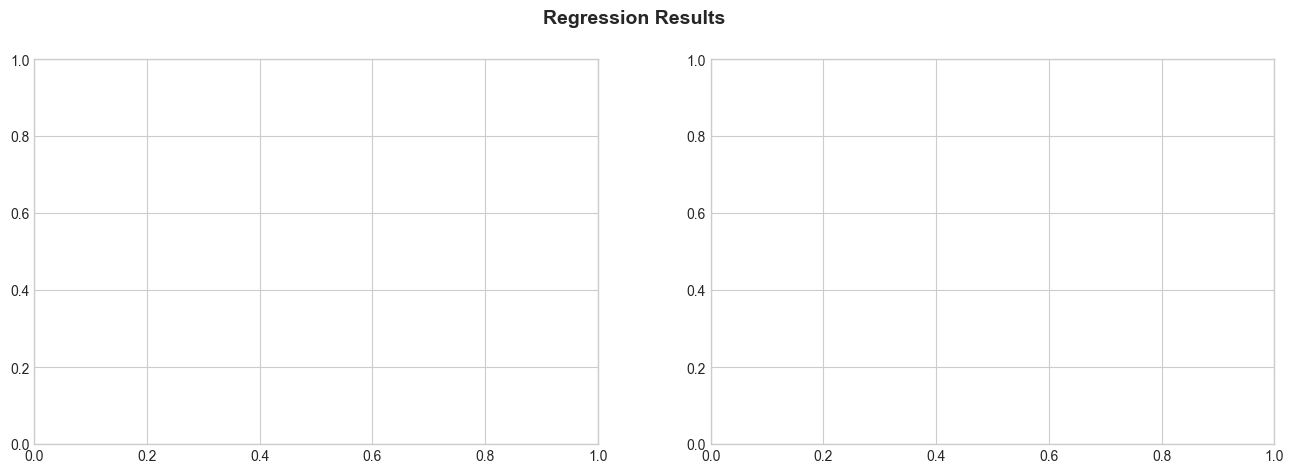

In [37]:
# ── Regression plots ──────────────────────────────────────
fig5, axes = plt.subplots(1, 2, figsize=(16, 5))
fig5.suptitle("Regression Results", fontsize=14, fontweight="bold")

In [38]:
# R² comparison
rnames = list(reg_results.keys())
r2vals = [reg_results[n]["r2"] for n in rnames]
bars2 = axes[0].barh(rnames, r2vals, color=COLORS[:len(rnames)], edgecolor="white")
axes[0].set_xlabel("R² Score")
axes[0].set_title("Regression Model R² Comparison", fontsize=12, fontweight="bold")
axes[0].set_xlim(0, 1)
for bar, val in zip(bars2, r2vals):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                 f"{val:.3f}", va="center", fontsize=9)

In [39]:
# Actual vs Predicted scatter (best model)
best_preds = reg_results[best_reg_name]["preds"]
axes[1].scatter(y_test_r, best_preds, alpha=0.4, color="#7F77DD", s=25, label="Predictions")
mn = min(y_test_r.min(), best_preds.min())
mx = max(y_test_r.max(), best_preds.max())
axes[1].plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect fit")
axes[1].set_xlabel("Actual TotalPrice ($)")
axes[1].set_ylabel("Predicted TotalPrice ($)")
axes[1].set_title(f"Actual vs Predicted — {best_reg_name}", fontsize=12, fontweight="bold")
axes[1].legend()
 
plt.tight_layout()
plt.savefig("regression_results.png", dpi=150, bbox_inches="tight")
plt.close()
print("    ✅ Regression plots saved → regression_results.png")

    ✅ Regression plots saved → regression_results.png


In [40]:
# Feature importance (Random Forest Regressor)
rf_reg = regressors["Random Forest Regressor"]
fi_reg = pd.Series(rf_reg.feature_importances_, index=X_reg.columns).sort_values(ascending=False)
print("\n--- Top 10 Feature Importances (Random Forest Regressor) ---")
print(fi_reg.head(10).round(4).to_string())
 
fig6, ax = plt.subplots(figsize=(9, 5))
fi_reg.head(15).plot(kind="barh", ax=ax, color="#1D9E75", edgecolor="white")
ax.invert_yaxis()
ax.set_title("Top 15 Feature Importances — Random Forest Regressor",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance_reg.png", dpi=150, bbox_inches="tight")
plt.close()
print("    ✅ Feature importance (regression) saved → feature_importance_reg.png")


--- Top 10 Feature Importances (Random Forest Regressor) ---
UnitPrice                  0.5329
Quantity                   0.4666
ItemsInCart                0.0001
Month                      0.0001
DayOfWeek                  0.0001
Quarter                    0.0000
ReferralSource_Facebook    0.0000
Product_Monitor            0.0000
Year                       0.0000
CouponCode_FREESHIP        0.0000
    ✅ Feature importance (regression) saved → feature_importance_reg.png


─────────────────────────────────────────
### 7. FINAL SUMMARY

In [41]:
print("\n" + "=" * 60)
print("  FINAL SUMMARY")
print("=" * 60)
 
print("\n📊 CLASSIFICATION (Predict OrderStatus):")
for name, res in cls_results.items():
    marker = "⭐" if name == best_cls_name else "  "
    print(f"  {marker} {name:<25}  Test Acc = {res['test']:.4f}")
 
print("\n📈 REGRESSION (Predict TotalPrice):")
for name, res in reg_results.items():
    marker = "⭐" if name == best_reg_name else "  "
    print(f"  {marker} {name:<28}  R² = {res['r2']:.4f}  MAE = ${res['mae']:.2f}")
 
print("\n📁 Output files generated:")
files = [
    "eda_plots.png", "correlation_heatmap.png",
    "classification_results.png", "feature_importance_cls.png",
    "regression_results.png", "feature_importance_reg.png"
]
for f in files:
    print(f"    • {f}")
 
print("\n✅ All done! Project complete.")
 


  FINAL SUMMARY

📊 CLASSIFICATION (Predict OrderStatus):
     Logistic Regression        Test Acc = 0.2000
     Decision Tree              Test Acc = 0.2000
     Random Forest              Test Acc = 0.2042
  ⭐ Gradient Boosting          Test Acc = 0.2125
     K-Nearest Neighbors        Test Acc = 0.1917
     SVM                        Test Acc = 0.1958

📈 REGRESSION (Predict TotalPrice):
     Linear Regression             R² = 0.8882  MAE = $219.10
     Ridge Regression              R² = 0.8882  MAE = $219.12
     Lasso Regression              R² = 0.8882  MAE = $218.99
  ⭐ Random Forest Regressor       R² = 0.9997  MAE = $9.25
     Gradient Boosting Reg.        R² = 0.9991  MAE = $20.20

📁 Output files generated:
    • eda_plots.png
    • correlation_heatmap.png
    • classification_results.png
    • feature_importance_cls.png
    • regression_results.png
    • feature_importance_reg.png

✅ All done! Project complete.
